In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\ML-Dataset.csv")
df.head()


,RegionName,CountryName,State,City,PostalCode,WarehouseAddress,WarehouseName,EmployeeName,EmployeeEmail,EmployeePhone,...,CustomerName,CustomerAddress,CustomerCreditLimit,CustomerEmail,CustomerPhone,Status,OrderDate,OrderItemQuantity,PerUnitPrice,TotalItemQuantity
0,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Summer Payne,summer.payne@example.com,5151238181,...,Flor Stone,2904 S Salina St,5000,flor.stone@raytheon.com,13171234104,Shipped,17-Nov-16,132,469.99,122
1,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Rose Stephens,rose.stephens@example.com,5151238080,...,Lavera Emerson,"5344 Haverford Ave, Philadelphia",5000,lavera.emerson@plainsallamerican.com,13171234111,Shipped,20-Feb-17,124,519.99,123
2,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Annabelle Dunn,annabelle.dunn@example.com,5151234444,...,Fern Head,"1795 Wu Meng, Muang Chonburi",1200,fern.head@usfoods.com,18121234115,Canceled,03-Jan-17,92,800.74,123
3,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Tommy Bailey,tommy.bailey@example.com,5151234567,...,Shyla Ortiz,"Walpurgisstr 69, Munich",2400,shyla.ortiz@abbvie.com,13171234126,Pending,15-Oct-17,128,849.99,124
4,South America,United States of America,Texas,Southlake,26192,2014 Jabberwocky Rd,Southlake Texas,Blake Cooper,blake.cooper@example.com,5151234569,...,Jeni Levy,"Via Frenzy 6903, Roma",1200,jeni.levy@centene.com,18121214129,Shipped,09-Apr-17,106,109.99,125


In [3]:
df['Date'] = pd.to_datetime(df['OrderDate'])
df['Month'] = df['Date'].dt.to_period("M")
df['Revenue'] = df['PerUnitPrice'] * df['OrderItemQuantity']

C:\Users\user\AppData\Local\Temp\ipykernel_6240\390446380.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['OrderDate'])


In [4]:
df.groupby('CategoryName')['Revenue'].sum().sort_values(ascending=False)
df.groupby('ProductName')['Profit'].sum().sort_values(ascending=False)


ProductName
G.Skill RipjawsX (F3-1600C9Q-32GXM) DDR3 32 GB      2770.00
A-DATA (AX4U300038G16-SRS) 8GB DDR4                 1990.00
G.Skill TridentX (F3-2400C10D-8GTX) DDR3 8GB        1962.00
G.Skill Ripjaws V Series                            1833.04
Corsair Vengeance LPX (CMK16GX4M2B3000C15B) 16GB    1749.00
                                                     ...   
SanDisk SDSSDA-120G-G26                                0.00
Samsung MZ-V6P2T0BW                                    0.00
Samsung MZ-7KE256BW                                    0.00
Samsung MZ-V6E1T0                                      0.00
Seagate ST2000DX002                                    0.00
Name: Profit, Length: 275, dtype: float64

In [5]:
#average ordered quantity and status
g = df.groupby('Status')['OrderItemQuantity'].\
    agg(['max','min'])
g

,max,min
Status,,
Canceled,149,32
Pending,150,34
Shipped,157,32


<Axes: xlabel='Month'>

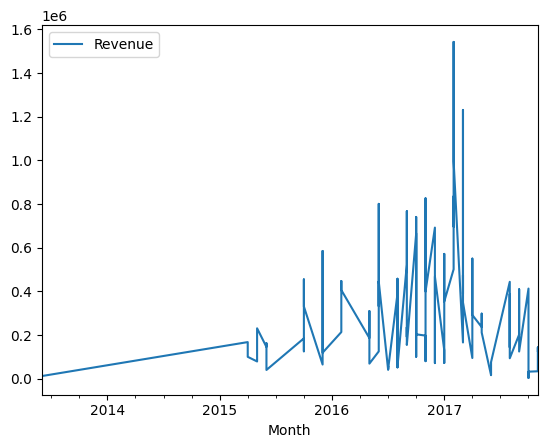

In [6]:
g = df.groupby(['Month','CategoryName'])['Revenue'].sum().reset_index()
g.plot(x='Month',y='Revenue')


<Axes: ylabel='CountryName'>

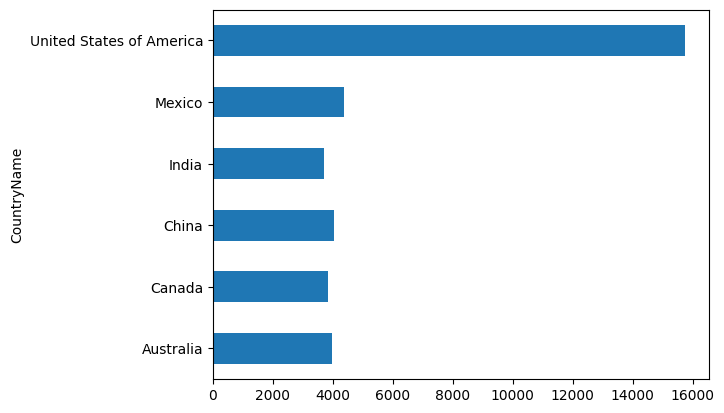

In [7]:
g = df.groupby('CountryName')['OrderItemQuantity'].sum()
g.plot(kind='barh')

In [8]:
p = df['PerUnitPrice'].quantile(.95)
q = df['OrderItemQuantity'].quantile(0.20)
d = df[(df['PerUnitPrice']>=p) & (df['OrderItemQuantity']>=q)]
d['Revenue'] = d['PerUnitPrice']*d['OrderItemQuantity']
g = d.groupby(['ProductName','PerUnitPrice'])['OrderItemQuantity'].sum().sort_values()
g.sort_values()

ProductName                           PerUnitPrice
MSI GTX 1080 TI LIGHTNING Z           4139.00          57
ASRock EP2C602-4L/D16                 2290.79          59
Supermicro X9SRH-7TF                  3254.99          82
Crucial CT525MX300SSD1                2799.99          86
Asus TUF X299 MARK 1                  3192.97          94
Hitachi HUA723020ALA640               2554.99          99
G.Skill Trident Z                     2699.99         112
Samsung MZ-75E120B/AM                 2998.89         115
MSI GeForce GTX 1080 Ti GAMING X 11G  2377.09         123
Kingston Fury (HX316C10FB/8) 8 GB     2998.89         130
Samsung MZ-V6E500                     4139.00         133
Western Digital WD5000AACS            2377.09         138
PNY SSD9SC240GMDA-RB                  4139.00         145
Name: OrderItemQuantity, dtype: int64

In [9]:
df.groupby('EmployeeName')['Revenue'].sum().sort_values()
#average revenue per order

EmployeeName
Rarrick Quinn           730.57
Billis Helen           1104.35
Cornett Lisa           1274.25
Moran Patrick          1889.55
Foreman Tanya          2351.44
                       ...    
LaRotonda William    328038.42
Leruth Giovanni      344872.35
Navathe Kurt         389855.70
Jackson Maryellen    550487.00
Shepard Anita        600155.00
Name: Revenue, Length: 400, dtype: float64

In [10]:
df.groupby('CustomerEmail')['Revenue'].mean()

CustomerEmail
JohnSnow@gmail.com                18546.88
LucyCechtelar@gmail.com          129052.43
PatronickLucas@gmail.com         106871.39
PearsonRandall@gmail.com          19239.63
PelletierErmine@gmail.com         36999.63
                                   ...    
wendell.massey@bbt.com            86993.62
willette.rodgers@pfgc.com         25499.66
willie.barrera@starbucks.com      22570.00
yolanda.ball@gamestopcorp.com     16754.82
yolando.wilkerson@oracle.com     130993.77
Name: Revenue, Length: 400, dtype: float64

<Axes: xlabel='CategoryName'>

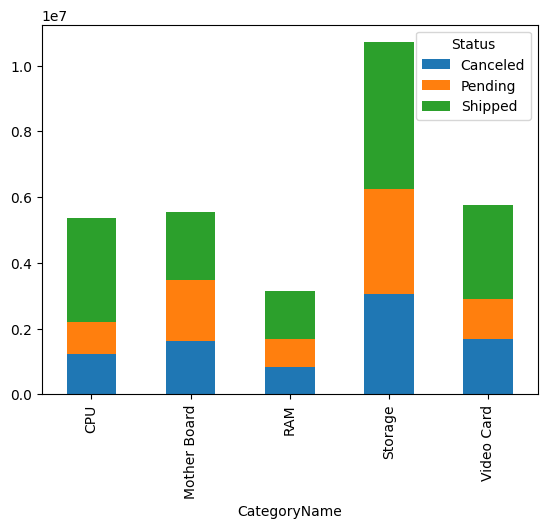

In [11]:
g = df.groupby(['CategoryName','Status'])['Revenue'].sum()
g.unstack(fill_value=0).plot(kind='bar',stacked=True)